In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.preprocessing import MinMaxScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [ ]:
csv_url = 'https://drive.google.com/uc?export=download&id=1hpsqSpfjdqIZWqwd259klQSeaNSe5Trr'
df = pd.read_csv(csv_url)

df.columns = df.columns.str.strip().str.lower()

if 'date' not in df.columns:
    if 'datetime' in df.columns:
        df.rename(columns={'datetime': 'date'}, inplace=True)
    elif 'time' in df.columns:
        df.rename(columns={'time': 'date'}, inplace=True)

df['date'] = pd.to_datetime(df['date'], format='mixed')
df.set_index('date', inplace=True)

if 'close' not in df.columns:
    for col in df.columns:
        if 'close' in col:
            df.rename(columns={col: 'close'}, inplace=True)
            break

df['rolling_mean_close'] = df['close'].rolling(window=24).mean()
df.dropna(inplace=True)

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if 'close' in numeric_cols:
    numeric_cols.remove('close')
if 'rolling_mean_close' in numeric_cols:
    numeric_cols.remove('rolling_mean_close')

fitur_tambahan = numeric_cols[:3]
features = fitur_tambahan + ['rolling_mean_close', 'close']
df = df[features]

print(f"Fitur yang digunakan: {features}")
print(f"Total baris data: {len(df)}")

Fitur yang digunakan: ['volume usdt', 'rsi', 'macd_hist', 'rolling_mean_close', 'close']
Total baris data: 53127


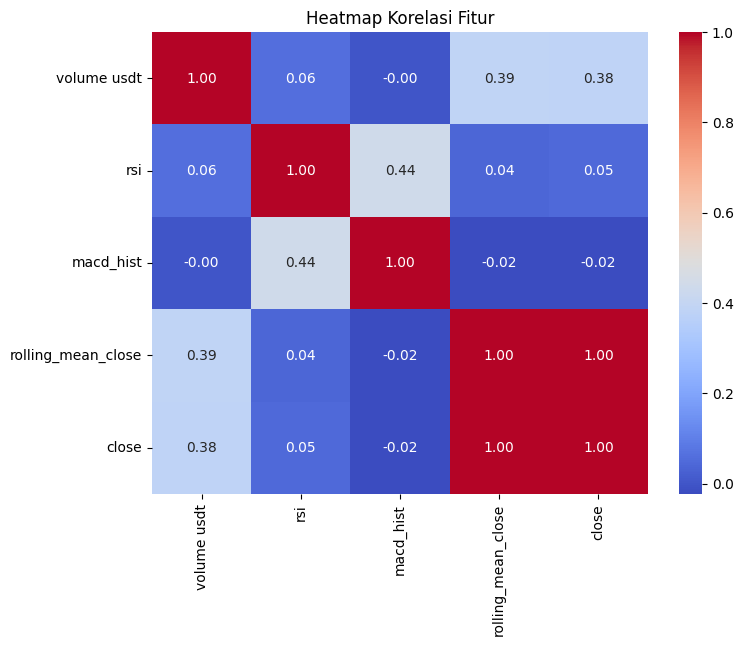

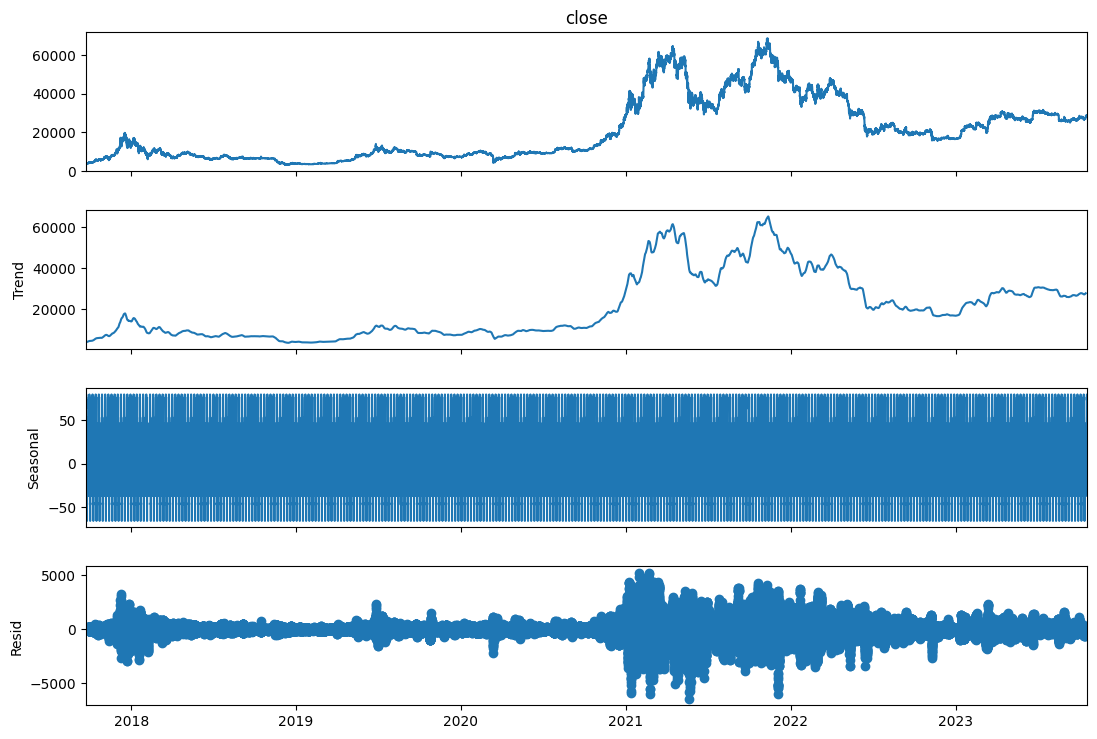

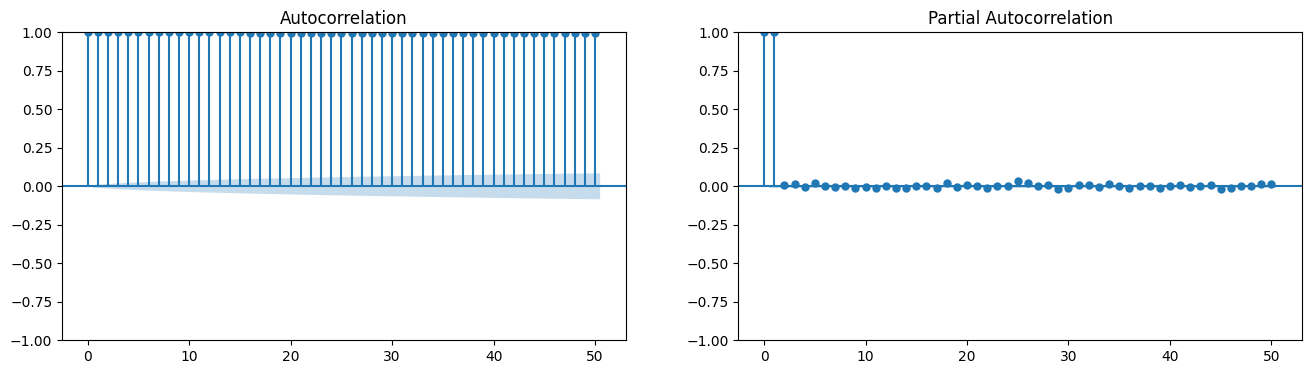

In [ ]:
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Heatmap Korelasi Fitur")
plt.show()

decompose = seasonal_decompose(df['close'], model='additive', period=24*7)
fig = decompose.plot()
fig.set_size_inches(12, 8)
plt.show()

fig, ax = plt.subplots(1, 2, figsize=(16, 4))
plot_acf(df['close'], lags=50, ax=ax[0])
plot_pacf(df['close'], lags=50, ax=ax[1])
plt.show()

In [ ]:
train_size = int(len(df) * 0.7)
val_size = int(len(df) * 0.15)

train_data = df.iloc[:train_size].copy()
val_data = df.iloc[train_size:train_size+val_size].copy()
test_data = df.iloc[train_size+val_size:].copy()

scalers = {}
for col in df.columns:
    scaler = MinMaxScaler()
    train_data[col] = scaler.fit_transform(train_data[[col]])
    val_data[col] = scaler.transform(val_data[[col]])
    test_data[col] = scaler.transform(test_data[[col]])

    if col == 'close':
        close_scaler = scaler

In [ ]:
window_size = 48
horizon = 24

def create_dataset(data, window_size, horizon):
    X, y = [], []
    data_values = data.values
    target_idx = data.columns.get_loc('close')
    for i in range(len(data_values) - window_size - horizon + 1):
        X.append(data_values[i : i + window_size])
        y.append(data_values[i + window_size : i + window_size + horizon, target_idx])
    return np.array(X), np.array(y)

X_train, y_train = create_dataset(train_data, window_size, horizon)
X_val, y_val = create_dataset(val_data, window_size, horizon)
X_test, y_test = create_dataset(test_data, window_size, horizon)

batch_size = 64
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

print(f"Bentuk X_train: {X_train.shape}")
print(f"Bentuk y_train: {y_train.shape}")

Bentuk X_train: (37117, 48, 5)
Bentuk y_train: (37117, 24)


In [ ]:
tf.keras.backend.clear_session()

model_baseline = Sequential([
    LSTM(64, activation='relu', input_shape=(window_size, len(features))),
    Dense(32, activation='relu'),
    Dense(horizon)
])

model_baseline.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Memulai training Baseline LSTM...")
baseline_history = model_baseline.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[EarlyStopping(patience=3, restore_best_weights=True)]
)

model_baseline.save('model_baseline_LSTM.keras')
print("Baseline LSTM berhasil dilatih dan disimpan!")

Memulai training Baseline LSTM...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


580/580 ━━━━━━━━━━━━━━━━━━━━ 26s 41ms/step - loss: 0.0019 - mae: 0.0275 - val_loss: 0.0473 - val_mae: 0.1921
Epoch 2/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 40s 39ms/step - loss: 0.0143 - mae: 0.0606 - val_loss: 0.0221 - val_mae: 0.1354
Epoch 3/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 22s 37ms/step - loss: 0.0078 - mae: 0.0471 - val_loss: 0.0140 - val_mae: 0.1017
Epoch 4/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 21s 37ms/step - loss: 0.0057 - mae: 0.0401 - val_loss: 0.0132 - val_mae: 0.1000
Epoch 5/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 21s 36ms/step - loss: 0.0058 - mae: 0.0434 - val_loss: 0.0093 - val_mae: 0.0844
Epoch 6/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - loss: 0.0035 - mae: 0.0327 - val_loss: 0.0059 - val_mae: 0.0670
Epoch 7/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 23s 39ms/step - loss: 0.0023 - mae: 0.0279 - val_loss: 0.0026 - val_mae: 0.0449
Epoch 8/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 20s 35ms/step - loss: 8.0652e-04 - mae: 0.0177 - val_loss: 0.0024 - val_mae: 0.0437
Epoch 9/10
580/580 ━━━━━━━━━━━━━━━━━━━━ 21s 36m

In [ ]:
@tf.keras.utils.register_keras_serializable()
class CustomDense(tf.keras.layers.Layer):
    def __init__(self, units, activation=None, **kwargs):
        super(CustomDense, self).__init__(**kwargs)
        self.units = units
        self.activation = tf.keras.activations.get(activation)

    def build(self, input_shape):
        self.w = self.add_weight(shape=(input_shape[-1], self.units), initializer='random_normal', trainable=True)
        self.b = self.add_weight(shape=(self.units,), initializer='zeros', trainable=True)

    def call(self, inputs):
        output = tf.matmul(inputs, self.w) + self.b
        if self.activation is not None:
            output = self.activation(output)
        return output

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units, "activation": tf.keras.activations.serialize(self.activation)})
        return config

@tf.keras.utils.register_keras_serializable()
class CustomDropout(tf.keras.layers.Layer):
    def __init__(self, rate, **kwargs):
        super(CustomDropout, self).__init__(**kwargs)
        self.rate = rate

    def call(self, inputs, training=None):
        if training:
            return tf.nn.dropout(inputs, rate=self.rate)
        return inputs

    def get_config(self):
        config = super().get_config()
        config.update({"rate": self.rate})
        return config

@tf.keras.utils.register_keras_serializable()
class CustomMultiHeadAttention(tf.keras.layers.Layer):
    def __init__(self, num_heads, key_dim, **kwargs):
        super(CustomMultiHeadAttention, self).__init__(**kwargs)
        self.num_heads = num_heads
        self.key_dim = key_dim
        self.wq = tf.keras.layers.Dense(num_heads * key_dim)
        self.wk = tf.keras.layers.Dense(num_heads * key_dim)
        self.wv = tf.keras.layers.Dense(num_heads * key_dim)
        self.dense = tf.keras.layers.Dense(num_heads * key_dim)

    def split_heads(self, x, batch_size):
        x = tf.reshape(x, (batch_size, -1, self.num_heads, self.key_dim))
        return tf.transpose(x, perm=[0, 2, 1, 3])

    def call(self, query, value):
        batch_size = tf.shape(query)[0]
        q = self.split_heads(self.wq(query), batch_size)
        k = self.split_heads(self.wk(value), batch_size)
        v = self.split_heads(self.wv(value), batch_size)

        matmul_qk = tf.matmul(q, k, transpose_b=True)
        dk = tf.cast(tf.shape(k)[-1], tf.float32)
        scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)
        attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)
        output = tf.matmul(attention_weights, v)

        output = tf.transpose(output, perm=[0, 2, 1, 3])
        concat_attention = tf.reshape(output, (batch_size, -1, self.num_heads * self.key_dim))
        return self.dense(concat_attention)

    def get_config(self):
        config = super().get_config()
        config.update({"num_heads": self.num_heads, "key_dim": self.key_dim})
        return config

In [ ]:
inputs = tf.keras.Input(shape=(window_size, len(features)))
x = LSTM(64, return_sequences=True)(inputs)
x = CustomMultiHeadAttention(num_heads=2, key_dim=32)(x, x)
x = tf.keras.layers.GlobalAveragePooling1D()(x)
x = CustomDense(32, activation='relu')(x)
x = CustomDropout(0.2)(x)
outputs = CustomDense(horizon)(x)

model_baseline_advanced = tf.keras.Model(inputs, outputs)
model_baseline_advanced.compile(optimizer='adam', loss='mse', metrics=['mae'])

print("Arsitektur Baseline Advanced berhasil dibangun!")

Arsitektur Baseline Advanced berhasil dibangun!


In [ ]:
@tf.keras.utils.register_keras_serializable()
class Seq2SeqLSTM(tf.keras.Model):
    def __init__(self, units, horizon, **kwargs):
        super(Seq2SeqLSTM, self).__init__(**kwargs)
        self.units = units
        self.horizon = horizon
        self.encoder = tf.keras.layers.LSTM(units, return_state=True)
        self.decoder = tf.keras.layers.LSTM(units, return_sequences=True, return_state=True)
        self.mha = CustomMultiHeadAttention(num_heads=2, key_dim=32)
        self.fc = CustomDense(1)

    def call(self, inputs, training=False):
        encoder_inputs, decoder_inputs = inputs

        enc_out, state_h, state_c = self.encoder(encoder_inputs)
        dec_out, _, _ = self.decoder(decoder_inputs, initial_state=[state_h, state_c])

        attn_out = self.mha(dec_out, dec_out)
        output = self.fc(attn_out)

        return tf.squeeze(output, axis=-1)

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units, "horizon": self.horizon})
        return config

seq2seq_model = Seq2SeqLSTM(units=64, horizon=horizon)
print("Arsitektur Seq2Seq Teacher Forcing berhasil dibangun!")

Arsitektur Seq2Seq Teacher Forcing berhasil dibangun!


In [ ]:
class WeightedMAELoss(tf.keras.losses.Loss):
    def __init__(self, horizon, **kwargs):
        super(WeightedMAELoss, self).__init__(**kwargs)
        self.horizon = horizon
        self.weights = tf.constant([1.0 + (i * 0.1) for i in range(horizon)], dtype=tf.float32)

    def call(self, y_true, y_pred):
        error = tf.abs(y_true - y_pred)
        weighted_error = error * self.weights
        return tf.reduce_mean(weighted_error)

class CustomEarlyStoppingAndReduceLR:
    def __init__(self, patience=5, reduce_factor=0.5, reduce_patience=2, min_lr=1e-6):
        self.patience = patience
        self.reduce_factor = reduce_factor
        self.reduce_patience = reduce_patience
        self.min_lr = min_lr
        self.best_loss = float('inf')
        self.wait = 0
        self.reduce_wait = 0
        self.stopped_epoch = 0
        self.stop_training = False
        self.best_weights = None

    def on_epoch_end(self, epoch, val_loss, model, optimizer):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.wait = 0
            self.reduce_wait = 0
            self.best_weights = model.get_weights()
        else:
            self.wait += 1
            self.reduce_wait += 1

            if self.reduce_wait >= self.reduce_patience:
                old_lr = optimizer.learning_rate.numpy()
                new_lr = max(old_lr * self.reduce_factor, self.min_lr)
                optimizer.learning_rate.assign(new_lr)
                self.reduce_wait = 0

            if self.wait >= self.patience:
                self.stopped_epoch = epoch
                self.stop_training = True
                if self.best_weights is not None:
                    model.set_weights(self.best_weights)

In [12]:
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
loss_fn = WeightedMAELoss(horizon=horizon)
custom_callback = CustomEarlyStoppingAndReduceLR(patience=5, reduce_patience=2)

epochs = 15
print("Memulai Custom Training Loop Seq2Seq LSTM dengan Teacher Forcing...")

close_idx = features.index('close')

for epoch in range(epochs):
    epoch_loss_avg = tf.keras.metrics.Mean()
    val_loss_avg = tf.keras.metrics.Mean()

    for x_batch, y_batch in train_ds:
        x_batch = tf.cast(x_batch, tf.float32)
        y_batch = tf.cast(y_batch, tf.float32)

        first_step = tf.expand_dims(x_batch[:, -1, close_idx], axis=1)
        rest_steps = y_batch[:, :-1]
        shifted_y = tf.concat([first_step, rest_steps], axis=1)
        shifted_y_exp = tf.expand_dims(shifted_y, axis=-1)

        zeros_before = tf.zeros((tf.shape(x_batch)[0], horizon, close_idx), dtype=tf.float32)
        zeros_after = tf.zeros((tf.shape(x_batch)[0], horizon, len(features) - close_idx - 1), dtype=tf.float32)
        dec_input = tf.concat([zeros_before, shifted_y_exp, zeros_after], axis=-1)

        with tf.GradientTape() as tape:
            predictions = seq2seq_model([x_batch, dec_input], training=True)
            loss_value = loss_fn(y_batch, predictions)

        grads = tape.gradient(loss_value, seq2seq_model.trainable_variables)
        optimizer.apply_gradients(zip(grads, seq2seq_model.trainable_variables))
        epoch_loss_avg.update_state(loss_value)

    for x_val, y_val_batch in val_ds:
        x_val = tf.cast(x_val, tf.float32)
        y_val_batch = tf.cast(y_val_batch, tf.float32)

        first_step_val = tf.expand_dims(x_val[:, -1, close_idx], axis=1)
        rest_steps_val = y_val_batch[:, :-1]
        shifted_y_val = tf.concat([first_step_val, rest_steps_val], axis=1)
        shifted_y_val_exp = tf.expand_dims(shifted_y_val, axis=-1)

        zeros_before_val = tf.zeros((tf.shape(x_val)[0], horizon, close_idx), dtype=tf.float32)
        zeros_after_val = tf.zeros((tf.shape(x_val)[0], horizon, len(features) - close_idx - 1), dtype=tf.float32)
        dec_input_val = tf.concat([zeros_before_val, shifted_y_val_exp, zeros_after_val], axis=-1)

        val_predictions = seq2seq_model([x_val, dec_input_val], training=False)
        v_loss = loss_fn(y_val_batch, val_predictions)
        val_loss_avg.update_state(v_loss)

    train_loss = epoch_loss_avg.result().numpy()
    val_loss = val_loss_avg.result().numpy()
    current_lr = optimizer.learning_rate.numpy()

    print(f"Epoch {epoch+1:02d}/{epochs:02d} - loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - lr: {current_lr:.6f}")

    custom_callback.on_epoch_end(epoch, val_loss, seq2seq_model, optimizer)
    if custom_callback.stop_training:
        print(f"Early stopping dipicu pada epoch {epoch+1}")
        break

seq2seq_model.save('model_seq2seq_LSTM.keras')
print("Model Seq2Seq berhasil dilatih dan disimpan!")

Memulai Custom Training Loop Seq2Seq LSTM dengan Teacher Forcing...
Epoch 01/15 - loss: 0.0343 - val_loss: 0.2579 - lr: 0.001000
Epoch 02/15 - loss: 0.0665 - val_loss: 0.3099 - lr: 0.001000
Epoch 03/15 - loss: 0.0713 - val_loss: 0.2895 - lr: 0.001000
Epoch 04/15 - loss: 0.0642 - val_loss: 0.2438 - lr: 0.000500
Epoch 05/15 - loss: 0.0378 - val_loss: 0.1716 - lr: 0.000500
Epoch 06/15 - loss: 0.0299 - val_loss: 0.1151 - lr: 0.000500
Epoch 07/15 - loss: 0.0213 - val_loss: 0.0741 - lr: 0.000500
Epoch 08/15 - loss: 0.0157 - val_loss: 0.0611 - lr: 0.000500
Epoch 09/15 - loss: 0.0128 - val_loss: 0.0366 - lr: 0.000500
Epoch 10/15 - loss: 0.0102 - val_loss: 0.0466 - lr: 0.000500
Epoch 11/15 - loss: 0.0114 - val_loss: 0.0396 - lr: 0.000500
Epoch 12/15 - loss: 0.0108 - val_loss: 0.0220 - lr: 0.000250
Epoch 13/15 - loss: 0.0103 - val_loss: 0.0268 - lr: 0.000250
Epoch 14/15 - loss: 0.0102 - val_loss: 0.0339 - lr: 0.000250
Epoch 15/15 - loss: 0.0101 - val_loss: 0.0272 - lr: 0.000125
Model Seq2Seq ber

Total MAE Seq2Seq (Scaled): 0.01578


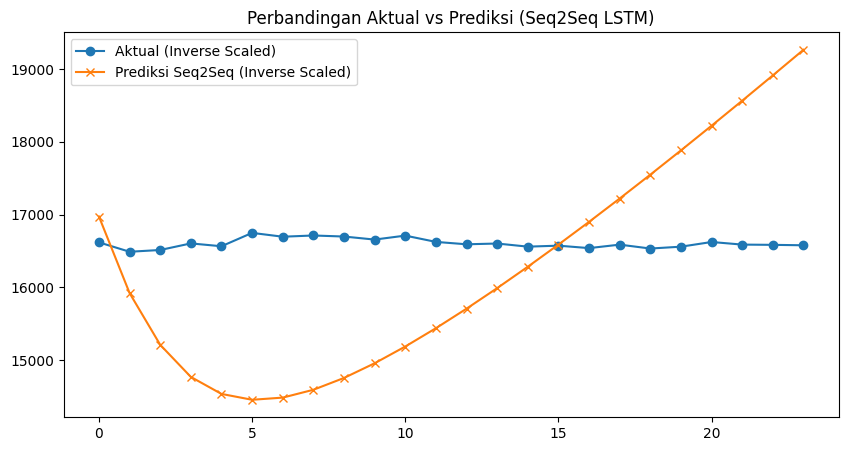



Total MAE Baseline LSTM (Scaled): 0.04528


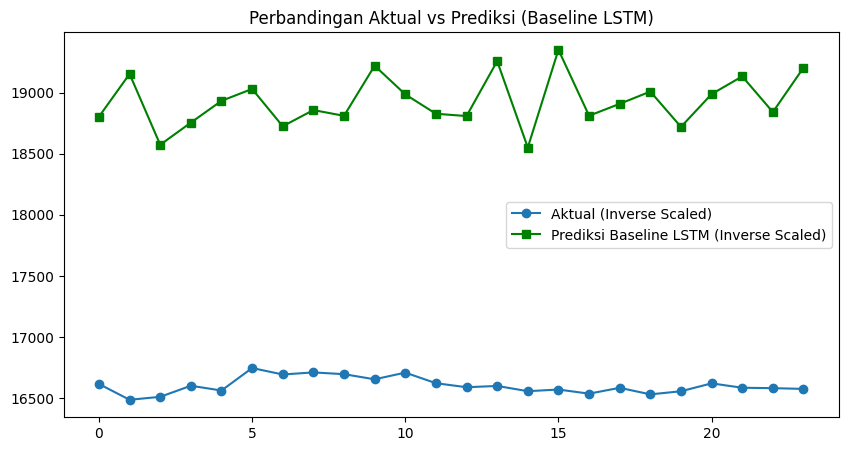

In [13]:
test_loss_avg = tf.keras.metrics.Mean()
close_idx = features.index('close')

for x_test, y_test_batch in test_ds:
    x_test = tf.cast(x_test, tf.float32)
    y_test_batch = tf.cast(y_test_batch, tf.float32)

    first_step_test = tf.expand_dims(x_test[:, -1, close_idx], axis=1)
    rest_steps_test = y_test_batch[:, :-1]
    shifted_y_test = tf.concat([first_step_test, rest_steps_test], axis=1)
    shifted_y_test_exp = tf.expand_dims(shifted_y_test, axis=-1)

    zeros_before_test = tf.zeros((tf.shape(x_test)[0], horizon, close_idx), dtype=tf.float32)
    zeros_after_test = tf.zeros((tf.shape(x_test)[0], horizon, len(features) - close_idx - 1), dtype=tf.float32)
    dec_input_test = tf.concat([zeros_before_test, shifted_y_test_exp, zeros_after_test], axis=-1)

    test_preds = seq2seq_model([x_test, dec_input_test], training=False)
    test_loss_avg.update_state(tf.reduce_mean(tf.abs(y_test_batch - test_preds)))

print(f"Total MAE Seq2Seq (Scaled): {test_loss_avg.result().numpy():.5f}")

test_batch_x, test_batch_y = next(iter(test_ds.take(1)))
test_sample_x = tf.cast(test_batch_x[0:1], tf.float32)
test_sample_y = tf.cast(test_batch_y[0:1], tf.float32)

enc_out, state_h, state_c = seq2seq_model.encoder(test_sample_x)
dec_input_step = tf.zeros((1, 1, test_sample_x.shape[2]), dtype=tf.float32)

predictions_ar = []
curr_h, curr_c = state_h, state_c

for t in range(horizon):
    dec_out, curr_h, curr_c = seq2seq_model.decoder(dec_input_step, initial_state=[curr_h, curr_c])
    attn_out = seq2seq_model.mha(dec_out, dec_out)
    step_pred = seq2seq_model.fc(attn_out)
    step_pred_val = tf.squeeze(step_pred, axis=-1)
    predictions_ar.append(step_pred_val[0, 0].numpy())

    new_dec_input = np.zeros((1, 1, test_sample_x.shape[2]), dtype=np.float32)
    new_dec_input[0, 0, close_idx] = step_pred_val[0, 0].numpy()
    dec_input_step = tf.convert_to_tensor(new_dec_input, dtype=tf.float32)

predictions_ar = np.array(predictions_ar).reshape(-1, 1)
actual_y = test_sample_y.numpy().reshape(-1, 1)

dummy_pred = np.zeros((horizon, len(features)))
dummy_pred[:, close_idx] = predictions_ar[:, 0]
inv_predictions = close_scaler.inverse_transform(dummy_pred)[:, close_idx]

dummy_actual = np.zeros((horizon, len(features)))
dummy_actual[:, close_idx] = actual_y[:, 0]
inv_actual = close_scaler.inverse_transform(dummy_actual)[:, close_idx]

plt.figure(figsize=(10, 5))
plt.plot(inv_actual, label='Aktual (Inverse Scaled)', marker='o')
plt.plot(inv_predictions, label='Prediksi Seq2Seq (Inverse Scaled)', marker='x')
plt.title("Perbandingan Aktual vs Prediksi (Seq2Seq LSTM)")
plt.legend()
plt.show()

print("\n" + "="*50 + "\n")

baseline_metrics = model_baseline.evaluate(test_ds, verbose=0)
print(f"Total MAE Baseline LSTM (Scaled): {baseline_metrics[1]:.5f}")

baseline_preds = model_baseline.predict(test_sample_x, verbose=0)

dummy_pred_base = np.zeros((horizon, len(features)))
dummy_pred_base[:, close_idx] = baseline_preds[0]
inv_predictions_base = close_scaler.inverse_transform(dummy_pred_base)[:, close_idx]

plt.figure(figsize=(10, 5))
plt.plot(inv_actual, label='Aktual (Inverse Scaled)', marker='o')
plt.plot(inv_predictions_base, label='Prediksi Baseline LSTM (Inverse Scaled)', marker='s', color='green')
plt.title("Perbandingan Aktual vs Prediksi (Baseline LSTM)")
plt.legend()
plt.show()

In [14]:
import os
from google.colab import files

!pip freeze > requirements.txt

with open('README.md', 'w') as f:
    f.write("# Proyek Time Series Forecasting\n\nProyek ini membangun arsitektur Seq2Seq LSTM dengan Custom Training Loop, Custom Loss (Weighted Horizon), Custom Callback, dan Multi-Head Attention untuk memprediksi nilai Bitcoin.")

!rm -f Submission_Akhir_DLTM.zip
!zip -r Submission_Akhir_DLTM.zip model_baseline_LSTM.keras model_seq2seq_LSTM.keras requirements.txt README.md

files.download('Submission_Akhir_DLTM.zip')

  adding: model_baseline_LSTM.keras (deflated 25%)
  adding: model_seq2seq_LSTM.keras (deflated 18%)
  adding: requirements.txt (deflated 57%)
  adding: README.md (deflated 25%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>